<a href="https://colab.research.google.com/github/Pentaphone/nn_tests/blob/main/nn_test2/nn_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Setup

In [144]:
# installs, imports
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2 as transforms

!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("markinsuff/lipophilicity") + "/Lipophilicity.csv"
print("Path to dataset:", path)
print()

!pip install rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors


# config
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

batch_size = 64
learning_rate = 1e-3
weight_decay = 0.01
epochs = 10


# util
def rand_index(dataset):
  return torch.randint(0, len(dataset), (1,)).item()

def smiles_to_img(smiles):
  mol = Chem.MolFromSmiles(smiles)
  return Draw.MolToImage(mol)

def smiles_to_fp(smiles):
  mol = Chem.MolFromSmiles(smiles)
  fp = fp_gen.GetFingerprint(mol)

  fp_tensor = torch.zeros(2048)
  for j, bit in enumerate(fp):
    fp_tensor[j] = bit

  return fp_tensor


Using Colab cache for faster access to the 'lipophilicity' dataset.
Path to dataset: /kaggle/input/lipophilicity/Lipophilicity.csv



### Data

In [76]:
# data
class LipophilicityDataset(torch.utils.data.Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
      if torch.is_tensor(i):
        i = i.tolist()

      fp_tensor = smiles_to_fp(self.data.loc[i, "RDKIT_SMILES"])
      exp = self.data.loc[i, "exp"]

      return (fp_tensor, exp)

    def get_data(self):
      return self.data

dataset = LipophilicityDataset(path)

training_data, test_data = torch.utils.data.random_split(dataset, [0.85, 0.15])

training_loader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

### Data Examples

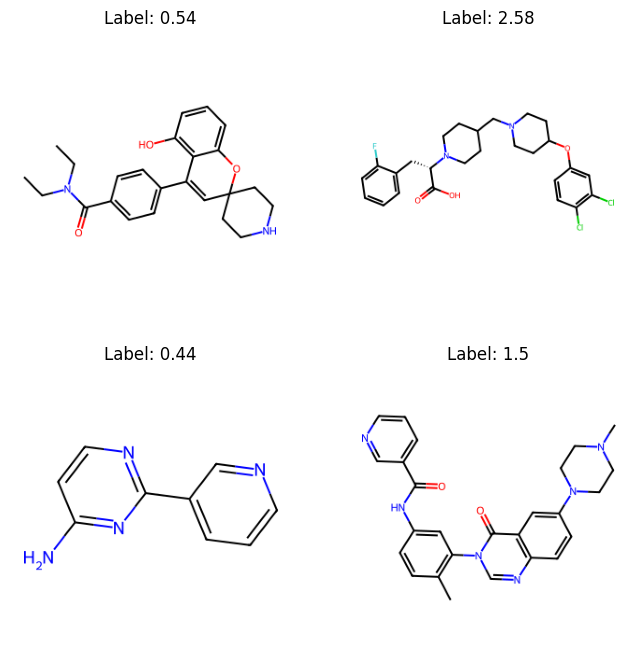

In [77]:
# examples
plt.figure(figsize=(8, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)

    data = pd.read_csv(path)
    rand_index = torch.randint(0, len(training_data)-4, (1,)).item()
    smiles = data.loc[rand_index, "RDKIT_SMILES"]
    label = data.loc[rand_index, "exp"]
    image = smiles_to_img(smiles)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

### Model

In [78]:
# model
class NeuralNet(nn.Module):
  def __init__(self) -> None:
    super().__init__()

    self.net = nn.Sequential(
      nn.Linear(2048, 1024),
      nn.ReLU(),
      nn.BatchNorm1d(1024),
      nn.Dropout(0.2),

      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.BatchNorm1d(512),
      nn.Dropout(0.2),

      nn.Linear(512, 128),
      nn.ReLU(),
      nn.Linear(128, 1)
      )

  def forward(self, x):
        return self.net(x)

model = NeuralNet()


### Training and Testing

In [145]:
from math import e
# training
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

eval_initial_performance = False
eval_between_epochs = False


def train(dataloader, model, loss_fn, optimizer):
  len_dataset = len(dataloader.dataset)
  model.train()
  for batch, (X, y) in enumerate(dataloader):
    output = model(X)
    y = y.unsqueeze(1).float()
    loss = loss_fn(output, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 5 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"loss: {loss:>7f}  [{current:>5d}/{len_dataset:>5d}]")

  print()

# testing
def evaluate(dataloader, model, loss_fn, dataset_name="test data"):
  print(f"Evaluate")
  len_dataset = len(dataloader.dataset)
  total_loss = 0

  model.eval()
  with torch.no_grad():
    for batch, (X, y) in enumerate(dataloader):
      pred = model(X)
      y = y.unsqueeze(1).float()
      total_loss += loss_fn(pred, y).item()

      if batch % 5 == 0:
        current = batch * len(X)
        print(f"[{current:>5d}/{len_dataset:>5d}]")

    total_loss = total_loss / len(dataloader)

  print(f"[{len_dataset:>5d}/{len_dataset:>5d}]")
  print(f"Average loss ({dataset_name}): {total_loss:>8f}\n")


# training cycle
if eval_initial_performance:
  print("Initial Model Performance:")
  evaluate(training_loader, model, loss_fn, dataset_name="training data")
  evaluate(test_loader, model, loss_fn, dataset_name="test data")

for epoch in range(epochs):
  print(f"Eppoch {epoch+1}/{epochs}")
  train(training_loader, model, loss_fn, optimizer)
  if eval_between_epochs:
    evaluate(training_loader, model, loss_fn, dataset_name="training data")
    evaluate(test_loader, model, loss_fn, dataset_name="test data")

if eval_between_epochs == False:
  evaluate(training_loader, model, loss_fn, dataset_name="training data")
  evaluate(test_loader, model, loss_fn, dataset_name="test data")

print("Training and testing completed")


# total parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params}')

# save model
torch.save(model.state_dict(), 'model_weights.pth')
torch.save(model, 'model.pth')

Eppoch 1/2
loss: 0.076722  [    0/ 3570]
loss: 0.131171  [  320/ 3570]
loss: 0.160853  [  640/ 3570]
loss: 0.169699  [  960/ 3570]
loss: 0.102455  [ 1280/ 3570]
loss: 0.124784  [ 1600/ 3570]
loss: 0.128917  [ 1920/ 3570]
loss: 0.130549  [ 2240/ 3570]
loss: 0.158132  [ 2560/ 3570]
loss: 0.205562  [ 2880/ 3570]
loss: 0.092504  [ 3200/ 3570]
loss: 0.274849  [ 2750/ 3570]

Eppoch 2/2
loss: 0.112654  [    0/ 3570]
loss: 0.100755  [  320/ 3570]
loss: 0.119016  [  640/ 3570]
loss: 0.116508  [  960/ 3570]
loss: 0.109808  [ 1280/ 3570]
loss: 0.101502  [ 1600/ 3570]
loss: 0.140250  [ 1920/ 3570]
loss: 0.129466  [ 2240/ 3570]
loss: 0.149886  [ 2560/ 3570]
loss: 0.100747  [ 2880/ 3570]
loss: 0.127245  [ 3200/ 3570]
loss: 0.128360  [ 2750/ 3570]

Evaluate
[    0/ 3570]
[  320/ 3570]
[  640/ 3570]
[  960/ 3570]
[ 1280/ 3570]
[ 1600/ 3570]
[ 1920/ 3570]
[ 2240/ 3570]
[ 2560/ 3570]
[ 2880/ 3570]
[ 3200/ 3570]
[ 2750/ 3570]
[ 3570/ 3570]
Average loss (training data): 0.077555

Evaluate
[    0/  630]
[ 

### Prediction Example

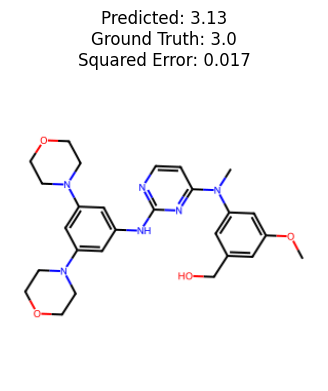

In [171]:
def pred_example(model, dataset, i=None):
  model.eval()

  # dataset argument is a Subset (like test_data). A Subset object does not have get_data(), but its underlying full dataset does.
  full_data = dataset.dataset.get_data()

  if i is None:
    idx_within_subset = torch.randint(0, len(dataset), (1,)).item()
    idx_within_full_data = dataset.indices[idx_within_subset]
  else:
    idx_within_full_data = i

  smiles = full_data.loc[idx_within_full_data, "RDKIT_SMILES"]
  image = smiles_to_img(smiles)
  formula = rdMolDescriptors.CalcMolFormula(Chem.MolFromSmiles(smiles))
  ground_truth = full_data.loc[idx_within_full_data, "exp"]

  fp_tensor = smiles_to_fp(smiles)
  pred = model(fp_tensor.unsqueeze(0)).squeeze(0).item()
  sq_error = (pred - ground_truth)**2

  plt.figure(figsize=(4,4))
  plt.axis("off")
  plt.title(f"Predicted: {pred:.2f}\nGround Truth: {ground_truth}\nSquared Error: {sq_error:.3f}")

  plt.imshow(image)

pred_example(model, test_data)